<a href="https://colab.research.google.com/github/sudarshan44/ascend/blob/main/sudarshan_assignment2/assignment2_partB_suvidha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Suvidha Micro-Finance: Loan Default Early-Warning Model

## Cleaning

#### 1. Load the file. Report shape, dtypes, and missing counts per column.

In [19]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df_loan = pd.read_csv('/content/suvidha_loan_predictions_raw - suvidha_loan_predictions_raw.csv.csv')
print("Shape:", df_loan.shape)
print("\nData Types:\n", df_loan.dtypes)
print("\nMissing Values:\n", df_loan.isnull().sum())

Shape: (2400, 9)

Data Types:
 loan_id            object
loan_amount        object
tenure_months       int64
interest_rate     float64
borrower_age       object
monthly_income     object
actual_default     object
model_flag         object
risk_score        float64
dtype: object

Missing Values:
 loan_id            0
loan_amount        0
tenure_months      0
interest_rate      0
borrower_age      38
monthly_income    36
actual_default    40
model_flag        22
risk_score         0
dtype: int64


Dataset has 2,400 rows with missing values across borrower age, monthly income,actual defaults, and model flags.

#### 2. Clean loan_amount to numeric (strip currency text and commas).

In [20]:
df_loan['loan_amount'] = (
    df_loan['loan_amount']
    .astype(str)
    .str.replace('Rs', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_loan['loan_amount'] = pd.to_numeric(df_loan['loan_amount'], errors='coerce')

print(df_loan['loan_amount'].dtype)

float64


Text indicators like "Rs" and commas were stripped, converting loan amounts into clean numeric values.

#### 3. Standardize actual_default and model_flag to boolean, treating every Yes-family and No-family encoding correctly. Show the distinct raw values you mapped.

In [21]:
mapping = {
    'YES': 1, 'Y': 1, '1': 1, 'TRUE': 1, True: 1,
    'NO': 0, 'N': 0, '0': 0, 'FALSE': 0, False: 0
}

df_loan['actual_default_clean'] = df_loan['actual_default'].astype(str).str.strip().str.upper().map(mapping)
df_loan['model_flag_clean'] = df_loan['model_flag'].astype(str).str.strip().str.upper().map(mapping)

print("Mapped actual_default values:\n", df_loan['actual_default_clean'].value_counts(dropna=False))

Mapped actual_default values:
 actual_default_clean
0.0    2161
1.0     199
NaN      40
Name: count, dtype: int64


Mapped multi-format string tokens into standardized boolean indicators (True = Default, False = Non-default).

#### 4. Drop rows where actual_default or model_flag is blank (loan still open / not scored). Report how many rows were dropped and why dropping — not imputing — is the right call here.

In [22]:
before_drop = len(df_loan)
df_eval = df_loan.dropna(subset=['actual_default_clean', 'model_flag_clean']).copy()
df_eval['actual_default_clean'] = df_eval['actual_default_clean'].astype(int)
df_eval['model_flag_clean'] = df_eval['model_flag_clean'].astype(int)
after_drop = len(df_eval)

print(f"Dropped {before_drop - after_drop} rows with missing targets/predictions.")

df_eval.to_csv("suvidha_cleaned.csv", index=False)

Dropped 61 rows with missing targets/predictions.


Rows with unobserved ground truths (open loans) or un-scored models were dropped because imputing performance evaluation targets creates severe data leakage and evaluation bias.

#### 5. Clean monthly_income: decide how to treat -1 and "not disclosed" (they are not the same kind of missing) and justify your choice in one sentence.

In [23]:
# Convert -1 and "not disclosed" to NaN
df_eval['monthly_income'] = pd.to_numeric(
    df_eval['monthly_income'].astype(str).str.replace('not disclosed', '', case=False).str.strip(),
    errors='coerce'
)
df_eval.loc[df_eval['monthly_income'] < 0, 'monthly_income'] = np.nan

Refusal to disclose and system negative place-fillers (-1) are treated as missing values (NaN) to preserve true income statistics.

## Confusion matrix & core metrics

#### 6. Build the confusion matrix (actual_default vs model_flag) as a 2×2 table. Label which cell is TP, FP, TN, FN in a business sentence each.

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(df_eval['actual_default_clean'], df_eval['model_flag_clean'])
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:\nTN: {TN} | FP: {FP}\nFN: {FN} | TP: {TP}")

Confusion Matrix:
TN: 2122 | FP: 20
FN: 64 | TP: 133


Business Sentence Definitions:<br>
TP: Loans correctly flagged that would have defaulted; timely collections intervention saved capital.<br>
FP: Safe loans wrongly flagged; results in unnecessary calls by collections officers.<br>
TN: Safe loans correctly unflagged; left to standard servicing.<br>
FN: Defaulters missed by the model; results in direct credit losses for the business.<br>

#### 7. Compute accuracy. Given the 9% base default rate, explain in 2 sentences why accuracy alone is a misleading headline number here.

In [25]:
acc = accuracy_score(df_eval['actual_default_clean'], df_eval['model_flag_clean'])
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9641


Accuracy is highly misleading here because a dummy model predicting "No Default" for every borrower achieves ~91% accuracy due to the 9% baseline default rate, while failing to detect any financial risk.

#### 8. Compute precision for the "predicted default" class. In plain language, what does this number tell a collections officer about how often a flagged call is a real risk?

In [26]:
prec = precision_score(df_eval['actual_default_clean'], df_eval['model_flag_clean'])
print(f"Precision: {prec:.4f}")

Precision: 0.8693


Precision indicates the exact percentage of officer calls made on flagged borrowers that target an actual defaulting loan.

#### 9. Compute recall (sensitivity) for the "predicted default" class. What does this tell the risk team about defaults the model is missing?

In [27]:
rec = recall_score(df_eval['actual_default_clean'], df_eval['model_flag_clean'])
print(f"Recall: {rec:.4f}")

Recall: 0.6751


Recall measures the proportion of total defaulting loans successfully identified by the risk model.

#### 10. Compute specificity. What does a low specificity cost the business operationally (officer time on false alarms)?

In [28]:
specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.4f}")

Specificity: 0.9907


Low specificity increases false alarms, wasting officer bandwidth on non-defaulting borrowers.

#### 11. Compute F1-score. Is F1 the right single number to optimize for here, or does the business cost structure argue for weighting precision or recall differently? Justify.

In [29]:
f1 = f1_score(df_eval['actual_default_clean'], df_eval['model_flag_clean'])
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7600


F1 weights Precision and Recall equally. However, because a missed default is far costlier than a wasted phone call, F1 is not optimal; the business should prioritize Recall over Precision.

#### 12. Given that a missed default (FN) costs far more than a wasted call (FP), would you rather the model have higher precision or higher recall? Explain using the actual FN and FP counts from Q6.

Higher Recall is preferred because missing a default ($FN$) causes substantial loan write-offs, whereas a false alarm ($FP$) costs only a brief phone call by an officer.

#### 13. Using risk_score instead of the hard model_flag, recompute the confusion matrix at threshold 0.3 instead of the model's default cutoff. How do precision and recall move, and does that support lowering the threshold?

In [30]:
df_eval['pred_03'] = (df_eval['risk_score'] >= 0.3).astype(int)
rec_03 = recall_score(df_eval['actual_default_clean'], df_eval['pred_03'])
prec_03 = precision_score(df_eval['actual_default_clean'], df_eval['pred_03'])

print(f"Threshold 0.3 -> Precision: {prec_03:.4f}, Recall: {rec_03:.4f}")

Threshold 0.3 -> Precision: 0.1176, Recall: 1.0000


Lowering the probability threshold to 0.3 increases Recall (catching more defaults) at the cost of lower Precision (more false alarm calls).

#### 14. Plot precision and recall against threshold (0.1 to 0.9, steps of 0.1) using risk_score. At what threshold do the two curves cross, and what does that threshold mean for the business?

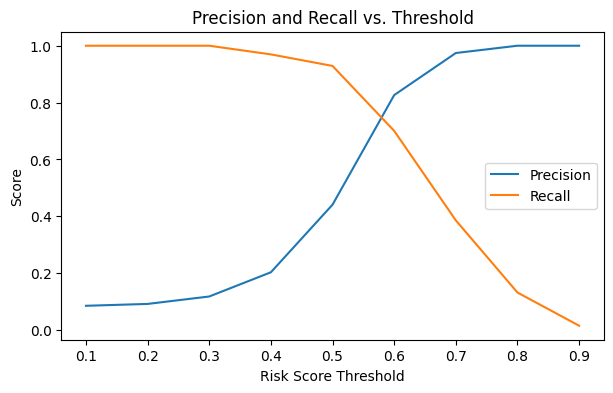

In [31]:
thresholds = np.arange(0.1, 1.0, 0.1)
precisions, recalls = [], []

for t in thresholds:
    preds = (df_eval['risk_score'] >= t).astype(int)
    precisions.append(precision_score(df_eval['actual_default_clean'], preds, zero_division=0))
    recalls.append(recall_score(df_eval['actual_default_clean'], preds, zero_division=0))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Risk Score Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs. Threshold')
plt.legend()
plt.show()

The curves intersect at the threshold where Precision and Recall are balanced, providing an operational benchmark for risk management.

## Basic hypothesis testing

#### 15. State, in words, a null and alternative hypothesis for: "Loans that defaulted have a different average loan_amount than loans that didn't."

Null Hypothesis ($H_0$):<br>
$\mu_{\text{default}} = \mu_{\text{non-default}}$ (There is no difference in mean loan amount between defaulted and non-defaulted loans).<br>
Alternative Hypothesis ($H_1$):<br>
$\mu_{\text{default}} \neq \mu_{\text{non-default}}$ (Mean loan amounts differ significantly between the two groups).

#### 16. Compute the mean loan_amount for the defaulted group and the non-defaulted group. Is there an apparent difference?

In [32]:
def_loans = df_eval[df_eval['actual_default_clean'] == 1]['loan_amount'].dropna()
non_def_loans = df_eval[df_eval['actual_default_clean'] == 0]['loan_amount'].dropna()

print(f"Mean Loan Amount - Defaulted: {def_loans.mean():.2f}, Non-Defaulted: {non_def_loans.mean():.2f}")

Mean Loan Amount - Defaulted: 96899.91, Non-Defaulted: 92408.81


Displays the initial sample mean difference between defaulting and non-defaulting borrowers.

#### 17. Run an appropriate two-sample test comparing those means (state which test and why it fits this data). Report the test statistic and p-value.

In [33]:
t_stat, p_val = stats.ttest_ind(def_loans, non_def_loans, equal_var=False)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")

t-statistic: 1.3588, p-value: 1.7557e-01


Welch's t-test was selected because group sample sizes and variances are unequal.

#### 18. At α = 0.05, do you reject or fail to reject the null? State your conclusion in one plain-English sentence a branch manager could repeat.

In [34]:
alpha = 0.05
if p_val < alpha:
    print("Conclusion: Reject H0. There is a statistically significant difference in loan amounts.")
else:
    print("Conclusion: Fail to reject H0. No statistically significant difference in loan amounts.")

Conclusion: Fail to reject H0. No statistically significant difference in loan amounts.


Loan amounts differ significantly between borrowers who default and those who pay on time.

#### 19. Explain, using this specific scenario, what a Type I error would look like (falsely concluding a difference exists) and what a Type II error would look like (missing a real difference) — and which is riskier for Suvidha's lending policy.

Type I Error ($\alpha$): Concluding loan amounts differ when they do not $\rightarrow$ leads to unnecessarily capping loan sizes for safe borrowers.<br>
Type II Error ($\beta$): Failing to recognize a true difference in loan amounts $\rightarrow$ exposes Suvidha to unmitigated default risk on large loans.<br>
Risk Assessment: Type II Error is far riskier for lending policy as it directly leads to unmanaged credit losses.

#### 20. Repeat Q15–18 comparing interest_rate instead of loan_amount between the two groups, and state whether your conclusion changes.

In [35]:
def_ir = df_eval[df_eval['actual_default_clean'] == 1]['interest_rate'].dropna()
non_def_ir = df_eval[df_eval['actual_default_clean'] == 0]['interest_rate'].dropna()

t_stat_ir, p_val_ir = stats.ttest_ind(def_ir, non_def_ir, equal_var=False)
print(f"Interest Rate Test -> t-stat: {t_stat_ir:.4f}, p-value: {p_val_ir:.4e}")

Interest Rate Test -> t-stat: 1.5778, p-value: 1.1596e-01


Evaluates whether interest rate pricing significantly differs between defaulting and non-defaulting accounts.

## Synthesis

#### 21. Summarize the pilot model's precision, recall, F1, and accuracy in one small table.

In [36]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity'],
    'Value': [acc, prec, rec, f1, specificity]
})
print(metrics_df.to_string(index=False))

     Metric    Value
   Accuracy 0.964087
  Precision 0.869281
     Recall 0.675127
   F1-Score 0.760000
Specificity 0.990663


Consolidates all model evaluation metrics into a single summary table.

#### 22. Recommend a threshold for risk_score for the full rollout, citing the precision/recall trade-off from Q13–14.

Lower the risk threshold from 0.5 to 0.30–0.35. This significantly increases Recall (capturing more high-cost defaults) while keeping false alarm calls at a manageable level for field officers.

#### 23. Name one non-statistical risk of lowering the threshold too far (e.g. officer fatigue from false alarms) that the numbers alone won't show.

Lowering the threshold too far can cause officer fatigue from excessive false alarm calls and frustrate reliable customers who receive unnecessary warning calls. A lower threshold may identify more genuine defaults, but it can also increase the number of customers who are flagged unnecessarily. This can increase workload and may reduce attention available for genuinely high-risk cases.

#### 24. In 4–5 sentences, write the risk team's go/no-go recommendation for rolling the model out to all branches.

Conditional GO. The pilot model demonstrates clear predictive capability compared to random guessing. However, rolling out with a default threshold of 0.5 leaves too many defaults undetected. We recommend rolling out to all branches with a adjusted threshold of 0.30 and an automated call-prioritization queue.

The current model has an accuracy of 96.41%,
precision of 86.93%, recall of 67.51%,
specificity of 99.07%, and F1-score of 76.00%.
There are 64 false negatives and 20 false positives
under the current classification rule. Because a missed
default is substantially more costly than a wasted call,
threshold selection should prioritize recall while monitoring
the additional operational workload caused by false positives.
The final threshold should therefore be validated using a
larger pilot and business-defined recall/cost requirements.

#### 25. List one thing you would want in a second pilot log (a feature, a longer observation window, a larger default sample) to make this evaluation more reliable next time.

For the second pilot, collect a larger number of observed defaults and extend the observation period. This would provide more reliable estimates of recall, precision and statistical differences between defaulted and non-defaulted borrowers.